# Tipping Point Experiment Analysis
This notebook visualizes the results of the tipping point experiment, which varies the proportion of `adverse` agents in the population.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load data
try:
    with open('log/tipping_point_experiment_results.json', 'r') as f:
        data = json.load(f)
except FileNotFoundError:
    print("Results file not found. Make sure to run `python experiment_tipping_points.py` first.")
    data = []

if data:
    proportions = [d['adverse_proportion'] for d in data]
    successful_projects = [d['successful_projects_count'] for d in data]
    societal_value = [d['total_societal_value'] for d in data]
    terminations = [d['total_terminations'] for d in data]
    avg_age = [d['avg_agent_age'] for d in data]

    # Extract populations
    populations = {
        'adverse': [],
        'careerist': [],
        'orthodox_scientist': [],
        'mass_producer': []
    }
    for d in data:
        pops = d['final_populations']
        for k in populations.keys():
            populations[k].append(pops.get(k, 0))
else:
    print("No data to plot.")

In [2]:
data

[{'adverse_proportion': 0.0,
  'total_societal_value': 1009.0362164814622,
  'total_rewards_distributed': 10964.119004967257,
  'successful_projects_count': 2362,
  'total_terminations': 2028,
  'avg_agent_age': 41.984,
  'final_populations': {'careerist': 49,
   'mass_producer': 111,
   'orthodox_scientist': 61},
  'success_rate': 0.38418998048145736},
 {'adverse_proportion': 0.05,
  'total_societal_value': 929.8795364027385,
  'total_rewards_distributed': 12541.667644750029,
  'successful_projects_count': 2303,
  'total_terminations': 1893,
  'avg_agent_age': 41.72366666666667,
  'final_populations': {'careerist': 48,
   'mass_producer': 105,
   'orthodox_scientist': 61},
  'success_rate': 0.401989876069122},
 {'adverse_proportion': 0.1,
  'total_societal_value': 914.9366381894114,
  'total_rewards_distributed': 13586.10344166966,
  'successful_projects_count': 2117,
  'total_terminations': 1854,
  'avg_agent_age': 41.872,
  'final_populations': {'adverse': 3,
   'careerist': 43,
   

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load data
try:
    with open('log/tipping_point_experiment_results.json', 'r') as f:
        data = json.load(f)
except FileNotFoundError:
    print("Results file not found. Make sure to run `python experiment_tipping_points.py` first.")
    data = []

if data:
    proportions = [d['adverse_proportion'] for d in data]
    successful_projects = [d['successful_projects_count'] for d in data]
    societal_value = [d['total_societal_value'] for d in data]
    terminations = [d['total_terminations'] for d in data]
    avg_age = [d['avg_agent_age'] for d in data]

    # Extract populations
    populations = {
        'adverse': [],
        'careerist': [],
        'orthodox_scientist': [],
        'mass_producer': []
    }
    for d in data:
        pops = d['final_populations']
        for k in populations.keys():
            populations[k].append(pops.get(k, 0))
else:
    print("No data to plot.")

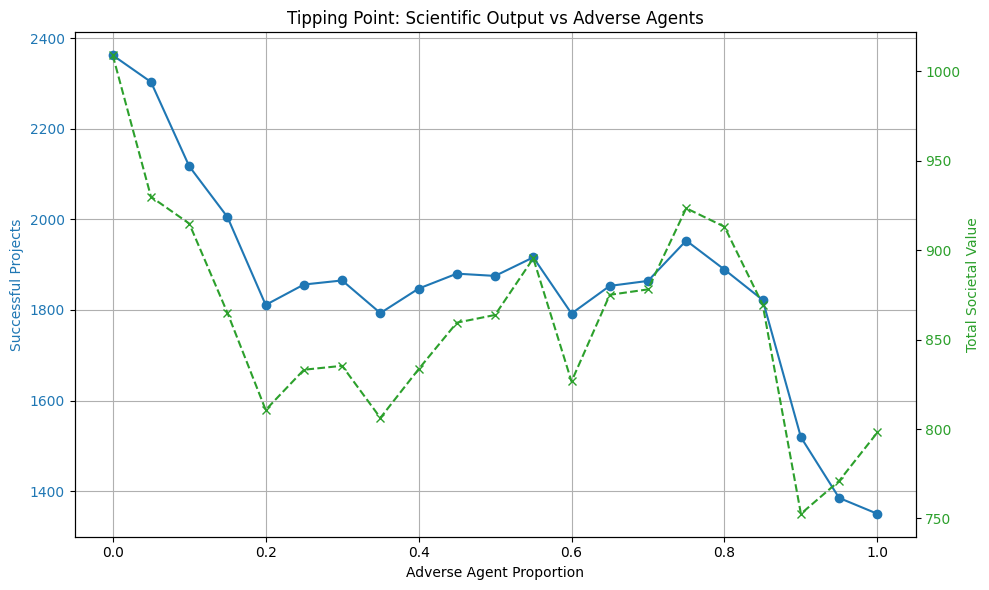

In [4]:
if data:
    fig, ax1 = plt.subplots(figsize=(10, 6))
    color = 'tab:blue'
    ax1.set_xlabel('Adverse Agent Proportion')
    ax1.set_ylabel('Successful Projects', color=color)
    ax1.plot(proportions, successful_projects, color=color, marker='o')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.set_ylabel('Total Societal Value', color=color)
    ax2.plot(proportions, societal_value, color=color, marker='x', linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Tipping Point: Scientific Output vs Adverse Agents')
    fig.tight_layout()
    plt.show()

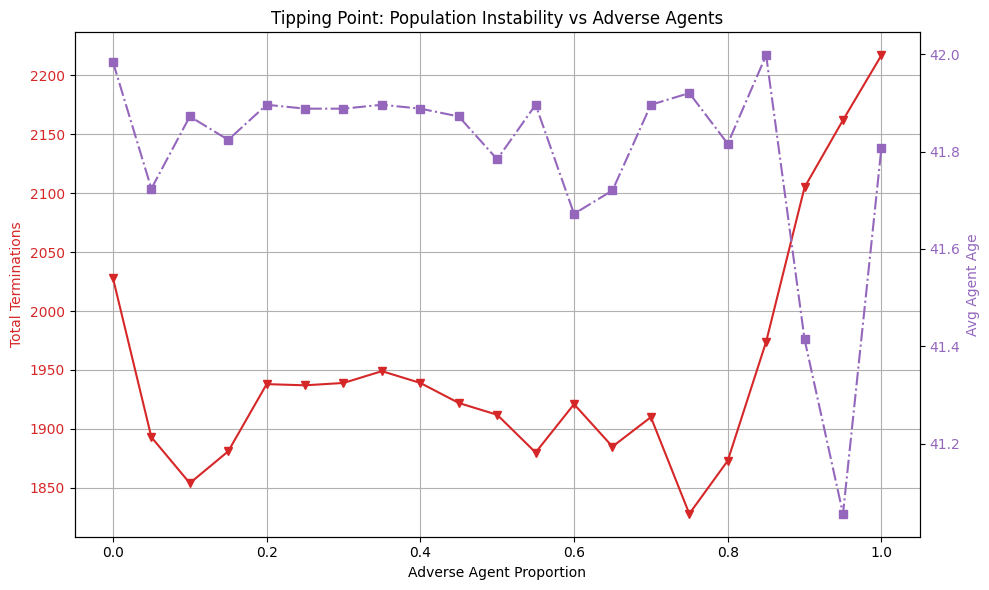

In [5]:
if data:
    fig, ax1 = plt.subplots(figsize=(10, 6))
    color = 'tab:red'
    ax1.set_xlabel('Adverse Agent Proportion')
    ax1.set_ylabel('Total Terminations', color=color)
    ax1.plot(proportions, terminations, color=color, marker='v')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    ax2 = ax1.twinx()
    color = 'tab:purple'
    ax2.set_ylabel('Avg Agent Age', color=color)
    ax2.plot(proportions, avg_age, color=color, marker='s', linestyle='-.')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Tipping Point: Population Instability vs Adverse Agents')
    fig.tight_layout()
    plt.show()

In [6]:
plt.rcParams.update({
    'font.size': 14
})

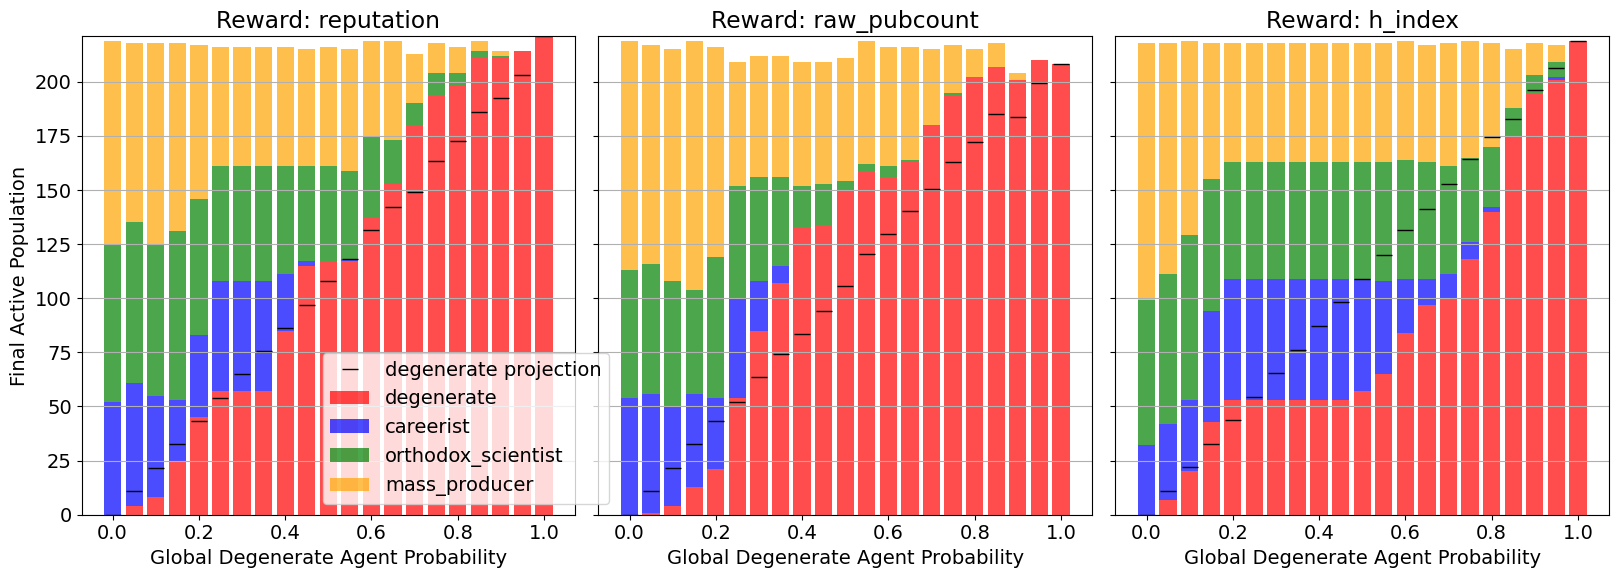

In [14]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

reward_types = ['reputation', 'raw_pubcount', 'h_index']
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

colors = {
    'adverse': 'red',
    'careerist': 'blue',
    'orthodox_scientist': 'green',
    'mass_producer': 'orange'
}

display_labels = {
    'adverse': 'degenerate',
    'careerist': 'careerist',
    'orthodox_scientist': 'orthodox_scientist',
    'mass_producer': 'mass_producer'
}

for i, reward_type in enumerate(reward_types):
    ax = axes[i]
    filepath = f"log/tipping_point_experiment_{reward_type}_results.json"
    
    data = []
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            # handle jsonl
            try:
                for line in f:
                    if line.strip():
                        data.append(json.loads(line))
            except json.JSONDecodeError:
                # maybe it's just a normal json list but named .jsonl
                f.seek(0)
                data = json.load(f)
    else:
        print("FILE NOT FOUND.")
                
    if data:
        proportions = [d['adverse_proportion'] for d in data]
        populations = {
            'adverse': [],
            'careerist': [],
            'orthodox_scientist': [],
            'mass_producer': []
        }
        for d in data:
            pops = d['final_populations']
            for k in populations.keys():
                populations[k].append(pops.get(k, 0))
                
        bottom = np.zeros(len(proportions))

        for policy, counts in populations.items():

            ax.bar(
                proportions,
                counts,
                width=0.04,
                label=display_labels.get(policy, policy),
                bottom=bottom,
                color=colors.get(policy, 'gray'),
                alpha=0.7
            )

            bottom += np.array(counts)

        # -----------------------------------
        # Black indicator:
        # expected degenerate proportion
        # -----------------------------------

        indicator_y = np.array(proportions) * bottom

        ax.plot(
            proportions,
            indicator_y,
            color='black',
            linewidth=2,
            linestyle='',
            marker='_',
            markersize=12,
            label='degenerate projection'
        )
            
        ax.set_title(f'Reward: {reward_type}')
        ax.set_xlabel('Global Degenerate Agent Probability')
        if i == 0:
            ax.set_ylabel('Final Active Population')
        ax.grid(True, axis='y')
    else:
        ax.text(0.5, 0.5, f"Data not found\n{filepath}", ha='center', va='center')
        ax.set_title(f'Reward: {reward_type}')

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.35, 0.41))

# plt.suptitle('Tipping Point: Final Population Composition across Reward Types', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.show()


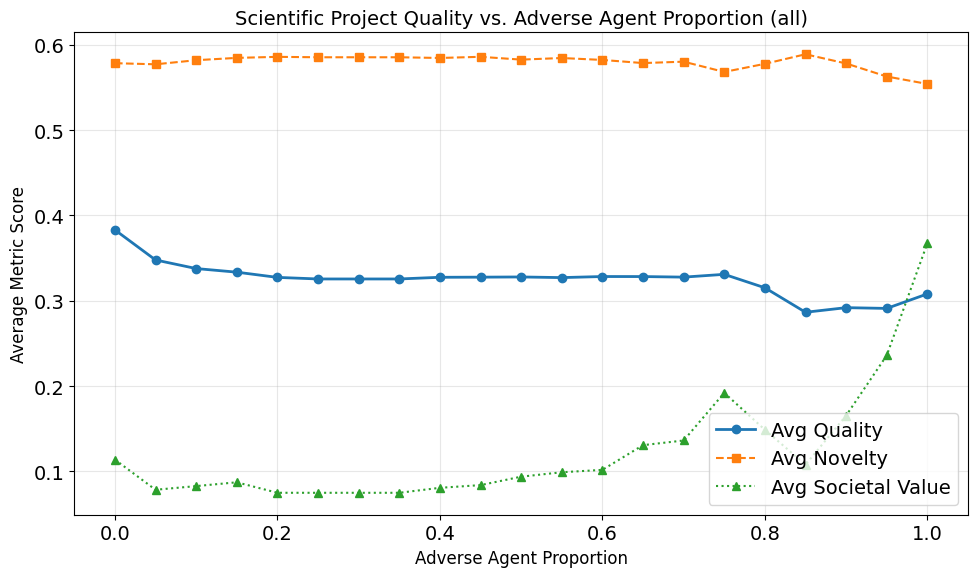

In [8]:
import glob
import re
import pandas as pd

def plot_project_quality_metrics(log_dir='log', reward_type='all'):
    """
    Reads quality metrics from project JSON files and graphs them against adverse proportions.
    """
    # Pattern to match your project files: log/tipping_point_adverse_0.90_all_projects.json
    pattern = os.path.join(log_dir, f"tipping_point_adverse_*_{reward_type}_projects.json")
    project_files = glob.glob(pattern)
    
    if not project_files:
        print(f"No files found matching pattern: {pattern}")
        return
    all_data = []
    for file_path in project_files:
        # Extract adverse proportion from filename (e.g., 0.90 from ...adverse_0.90_...)
        match = re.search(r"adverse_([\d\.]+)_", os.path.basename(file_path))
        if not match:
            continue
            
        adverse_proportion = float(match.group(1))
        
        try:
            with open(file_path, 'r') as f:
                projects = json.load(f)
            
            if not projects:
                continue
            # Process metrics for this specific run
            # Only considering finished projects provides a cleaner quality metric
            finished_projects = [p for p in projects if p.get('finished', False)]
            
            if finished_projects:
                avg_quality = sum(p.get('quality_score', 0) for p in finished_projects) / len(finished_projects)
                avg_novelty = sum(p.get('novelty_score', 0) for p in finished_projects) / len(finished_projects)
                avg_societal = sum(p.get('societal_value_score', 0) for p in finished_projects) / len(finished_projects)
                
                all_data.append({
                    "adverse_proportion": adverse_proportion,
                    "Quality": avg_quality,
                    "Novelty": avg_novelty,
                    "Societal Value": avg_societal
                })
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    # Create DataFrame and sort by proportion for clean plotting
    df = pd.DataFrame(all_data).sort_values("adverse_proportion")
    if df.empty:
        print("No project data could be processed.")
        return
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(df["adverse_proportion"], df["Quality"], marker='o', label="Avg Quality", linewidth=2)
    plt.plot(df["adverse_proportion"], df["Novelty"], marker='s', label="Avg Novelty", linestyle='--')
    plt.plot(df["adverse_proportion"], df["Societal Value"], marker='^', label="Avg Societal Value", linestyle=':')
    plt.title(f"Scientific Project Quality vs. Adverse Agent Proportion ({reward_type})", fontsize=14)
    plt.xlabel("Adverse Agent Proportion", fontsize=12)
    plt.ylabel("Average Metric Score", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
# Example usage (you can run this directly in a notebook cell)
plot_project_quality_metrics(reward_type='all')

/tmp/ipykernel_1799114/932073050.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1799114/932073050.py:54: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


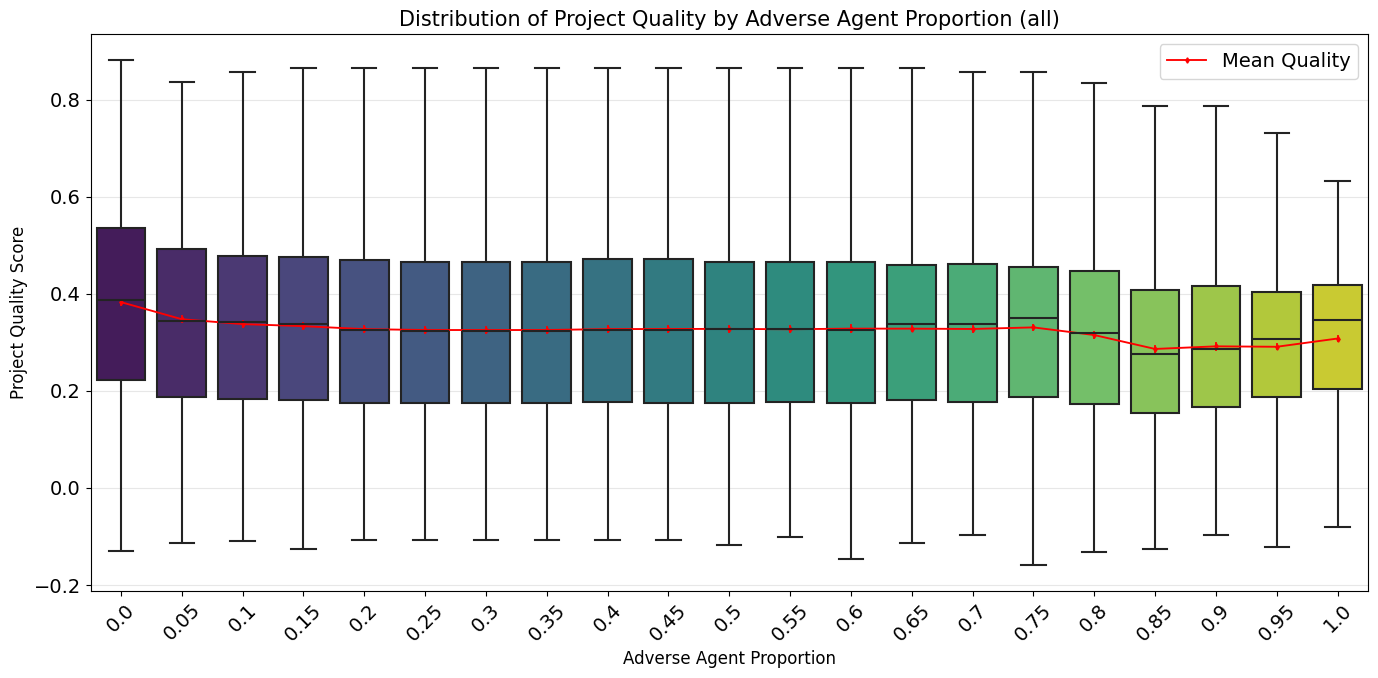

In [9]:
import seaborn as sns

def plot_quality_distribution(log_dir='log', reward_type='all'):
    """
    Plots the distribution of project quality scores per adverse proportion using box plots.
    """
    pattern = os.path.join(log_dir, f"tipping_point_adverse_*_{reward_type}_projects.json")
    project_files = glob.glob(pattern)
    
    if not project_files:
        print(f"No files found matching pattern: {pattern}")
        return
    rows = []
    for file_path in project_files:
        # Extract adverse proportion
        match = re.search(r"adverse_([\d\.]+)_", os.path.basename(file_path))
        if not match:
            continue
        proportion = float(match.group(1))
        
        try:
            with open(file_path, 'r') as f:
                projects = json.load(f)
            
            # Filter for finished projects and collect individual quality scores
            for p in projects:
                if p.get('finished', False):
                    rows.append({
                        "Adverse Proportion": proportion,
                        "Project Quality": p.get('quality_score', 0)
                    })
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    df = pd.DataFrame(rows)
    if df.empty:
        print("No project data could be processed.")
        return
    # Sort proportions for the x-axis
    df = df.sort_values("Adverse Proportion")
    # Plotting
    plt.figure(figsize=(14, 7))
    
    # Use seaborn to create the boxplot (Quartiles + Whiskers)
    # We treat 'Adverse Proportion' as the x grouping
    sns.boxplot(
        data=df, 
        x="Adverse Proportion", 
        y="Project Quality", 
        palette="viridis",
        showfliers=False,  # Set to True if you want to see outliers as dots
        linewidth=1.5
    )
    # Optional: Add a line connecting the means to see the trend clearly
    sns.pointplot(
        data=df, 
        x="Adverse Proportion", 
        y="Project Quality", 
        color='red', 
        markers='d', 
        scale=0.5,
        label="Mean Quality"
    )
    plt.title(f"Distribution of Project Quality by Adverse Agent Proportion ({reward_type})", fontsize=15)
    plt.xlabel("Adverse Agent Proportion", fontsize=12)
    plt.ylabel("Project Quality Score", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
# Run the visualization
plot_quality_distribution(reward_type='all')

/tmp/ipykernel_1799114/932073050.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1799114/932073050.py:54: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


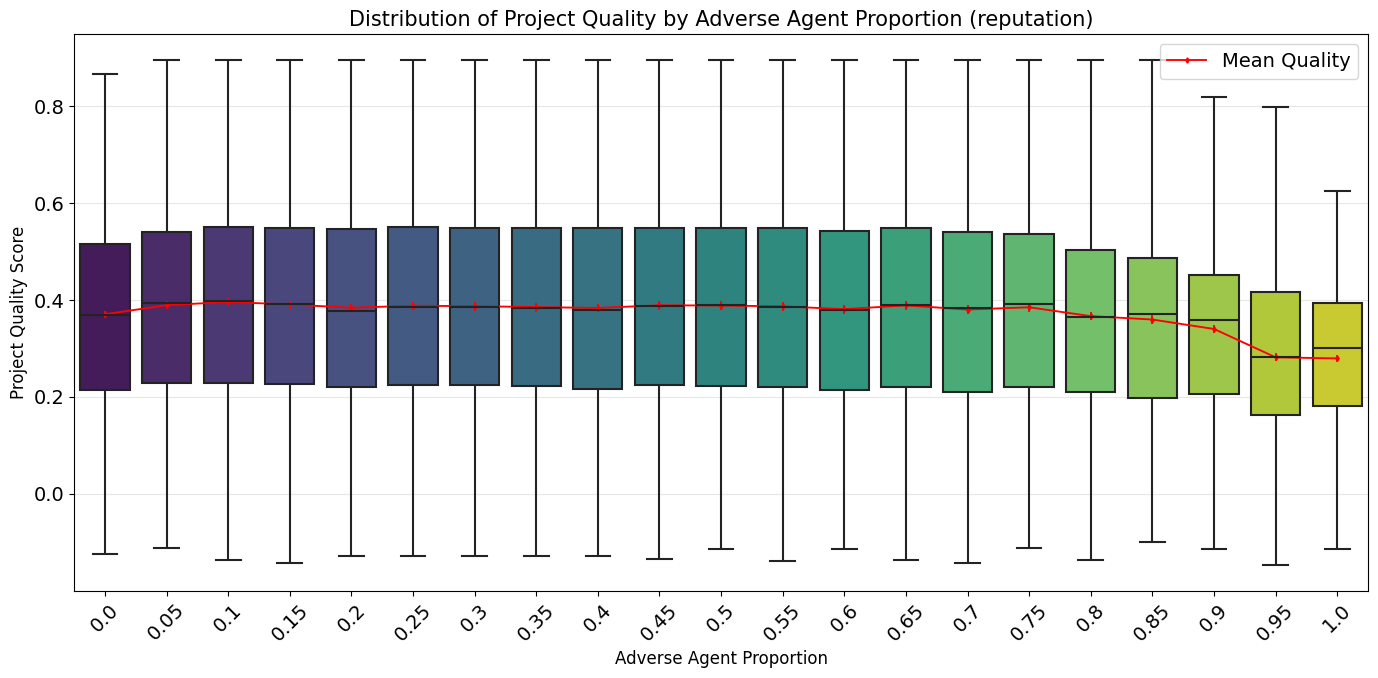

In [10]:
plot_quality_distribution(reward_type='reputation')